# IoT-Based Predictive Maintenance Using Vibration Signal Analysis and Fault Classification

**Department of Computer Science and Engineering, Ahsanullah University of Science and Technology (AUST), Dhaka**

| Member | ID |
|---|---|
| Tasfia Jannat | 20220104026 |
| Sanaf Salehin | 20220104063 |
| Afia Adilah | 20220104069 |
| Umme Ayesha Rahman | 20200204050 |

**What this notebook is:** a walkthrough of our project for review. It (1) summarises the system and the experimental results from our report, (2) opens up the **actual trained Random Forest that runs on the ESP32** (`model.h`) and inspects it, and (3) uses small **synthetic** demonstrations to explain two key ideas: the FFT / order analysis and why we used grouped cross-validation.

> **Honesty note.** Our raw sensor CSVs are not included in this notebook, so the results in Section 4 are the numbers reported in our paper (typed in from Tables V and VI), not re-computed here. Anything generated from synthetic data is labelled **SYNTHETIC** and is used only to illustrate a concept.

## 1. Problem and motivation

Unplanned downtime is a major hidden cost for rotating machinery. **Predictive maintenance (PdM)** monitors machine condition (vibration, temperature, current, ...) and infers health before a fault becomes a failure, unlike *reactive* maintenance (repair after failure) or *preventive* maintenance (fixed calendar).

Two gaps motivated the project:

1. Many low-cost PdM demos need a PC or cloud for classification, so they are not standalone field units.
2. Vibration data is recorded as long continuous runs cut into overlapping windows. If windows from the **same recording** land in both train and test sets, near-duplicates leak and accuracy is inflated.

**Contributions:** (i) a low-cost ESP32 motor test rig; (ii) a cleaned, labelled dataset with 37 engineered features; (iii) a six-classifier comparison with **grouped** cross-validation; (iv) a 12-tree Random Forest exported to C for **on-device** inference; (v) a live browser dashboard.

## 2. Hardware and wiring

In [ ]:
import pandas as pd
pd.set_option("display.max_colwidth", None)

hardware = pd.DataFrame([
    ["Microcontroller", "ESP32 DevKit V1", "Acquisition, motor control, inference"],
    ["Accelerometer / gyro", "MPU6050 (GY-521)", "3-axis accel + 3-axis gyro over I2C"],
    ["Speed sensor", "A3144 Hall + magnet", "Interrupt-driven pulse timing (RPM)"],
    ["Motor driver", "L298N H-bridge", "Direction and PWM speed control"],
    ["Motor", "12 V 775 DC", "Machine under test"],
    ["Fault simulation", "Off-centre weights, washers/shims", "Imbalance / misalignment"],
    ["Power", "12 V / 5 A adapter", "Motor supply, separate from ESP32"],
], columns=["Component", "Model", "Role"])
display(hardware)

pins = pd.DataFrame([
    ["GPIO 21", "MPU6050", "SDA (I2C data)"],
    ["GPIO 22", "MPU6050", "SCL (I2C clock)"],
    ["GPIO 27", "A3144", "OUT (RPM pulse input)"],
    ["GPIO 25", "L298N", "IN1 (direction)"],
    ["GPIO 26", "L298N", "IN2 (direction)"],
    ["GPIO 33", "L298N", "ENA (PWM speed)"],
], columns=["ESP32 pin", "Module", "Function"])
display(pins)

,Component,Model,Role
0,Microcontroller,ESP32 DevKit V1,"Acquisition, motor control, inference"
1,Accelerometer / gyro,MPU6050 (GY-521),3-axis accel + 3-axis gyro over I2C
2,Speed sensor,A3144 Hall + magnet,Interrupt-driven pulse timing (RPM)
3,Motor driver,L298N H-bridge,Direction and PWM speed control
4,Motor,12 V 775 DC,Machine under test
5,Fault simulation,"Off-centre weights, washers/shims",Imbalance / misalignment
6,Power,12 V / 5 A adapter,"Motor supply, separate from ESP32"


,ESP32 pin,Module,Function
0,GPIO 21,MPU6050,SDA (I2C data)
1,GPIO 22,MPU6050,SCL (I2C clock)
2,GPIO 27,A3144,OUT (RPM pulse input)
3,GPIO 25,L298N,IN1 (direction)
4,GPIO 26,L298N,IN2 (direction)
5,GPIO 33,L298N,ENA (PWM speed)


## 3. Signal processing and dataset

**Sampling:** the MPU6050 is read every 10 ms, so

$$f_s = \frac{1}{0.01\,\text{s}} = 100\ \text{Hz}$$

**RPM** from the Hall sensor (one pulse per revolution): $\text{RPM} = N_\text{pulses} / T_\text{min}$. The firmware equivalently uses the pulse period, $\text{RPM} = 60{,}000{,}000 / \text{period}_{\mu s}$.

**Rotational frequency and order:**

$$f_r = \frac{\text{RPM}}{60}, \qquad \text{Order} = \frac{f}{f_r}$$

Expressing frequencies as *orders* lets us compare vibration across different motor speeds. Imbalance typically shows up strongly at order 1 (once per revolution).

**Dataset evolution (from the report):** 2,970 raw labelled samples (7 raw features, 3 classes: forward-normal, reverse-normal, forward-imbalance) were cleaned, cut into fixed-length windows and turned into **900 windows x 37 features** (300 per class), each tagged with a recording-segment ID for grouped splitting.

### 3.1 Illustration: FFT and order analysis (SYNTHETIC)
This is a made-up signal, not our recorded data. It shows why an imbalance adds energy at order 1.

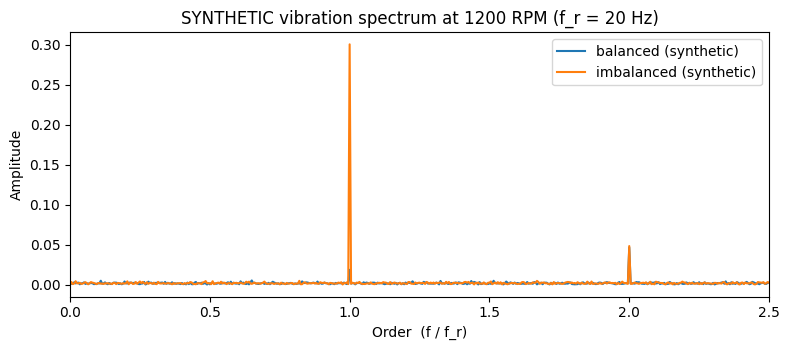

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fs = 100                 # Hz, same as our firmware
T = 10                   # seconds
t = np.arange(0, T, 1/fs)
rpm = 1200
fr = rpm / 60            # 20 Hz; its 2nd harmonic (40 Hz) is still below Nyquist (50 Hz)

rng = np.random.default_rng(0)
def vib(imbalance):
    x = 0.05*np.sin(2*np.pi*2*fr*t)            # small 2x component
    x += imbalance*np.sin(2*np.pi*fr*t)        # 1x component grows with imbalance
    x += 0.03*rng.standard_normal(len(t))      # sensor noise
    return x

fig, ax = plt.subplots(figsize=(8, 3.6))
for label, amp in [("balanced (synthetic)", 0.02), ("imbalanced (synthetic)", 0.30)]:
    x = vib(amp)
    X = np.abs(np.fft.rfft(x - x.mean())) * 2 / len(x)
    f = np.fft.rfftfreq(len(x), 1/fs)
    ax.plot(f / fr, X, label=label)
ax.set_xlabel("Order  (f / f_r)")
ax.set_ylabel("Amplitude")
ax.set_xlim(0, 2.5)
ax.set_title(f"SYNTHETIC vibration spectrum at {rpm} RPM (f_r = {fr:.0f} Hz)")
ax.legend()
plt.tight_layout(); plt.show()

## 4. Results reported in the paper

Values below are copied from **Table V** of our report (mean grouped 5-fold CV accuracy, error bars = one standard deviation across folds).

,Model,Mean acc,Std
0,Random Forest (300 trees),0.79,0.05
1,"Random Forest (12 trees, d=6) - deployed",0.84,0.09
2,SVM (RBF),0.77,0.06
3,Gradient Boosting,0.78,0.04
4,k-Nearest Neighbours,0.75,0.07
5,Logistic Regression,0.76,0.05
6,MLP,0.79,0.06


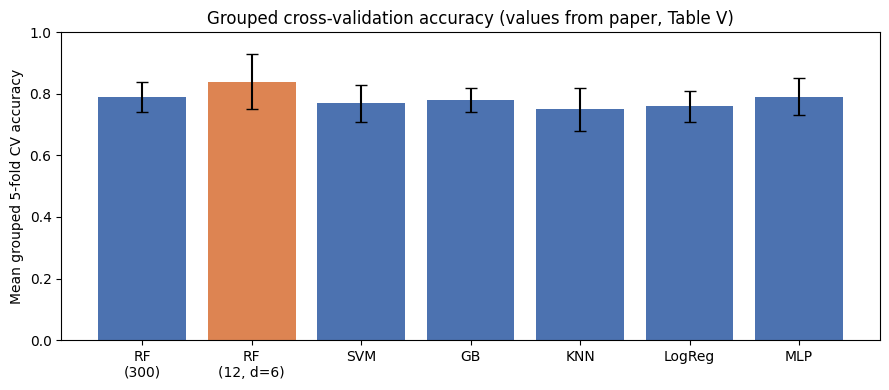

In [ ]:
results = pd.DataFrame({
    "Model": ["Random Forest (300 trees)", "Random Forest (12 trees, d=6) - deployed",
              "SVM (RBF)", "Gradient Boosting", "k-Nearest Neighbours",
              "Logistic Regression", "MLP"],
    "Mean acc": [0.79, 0.84, 0.77, 0.78, 0.75, 0.76, 0.79],
    "Std":      [0.05, 0.09, 0.06, 0.04, 0.07, 0.05, 0.06],
})
display(results)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#4c72b0"] * len(results)
colors[1] = "#dd8452"
ax.bar(range(len(results)), results["Mean acc"], yerr=results["Std"], capsize=4, color=colors)
ax.set_xticks(range(len(results)))
ax.set_xticklabels(["RF\n(300)", "RF\n(12, d=6)", "SVM", "GB", "KNN", "LogReg", "MLP"])
ax.set_ylim(0, 1)
ax.set_ylabel("Mean grouped 5-fold CV accuracy")
ax.set_title("Grouped cross-validation accuracy (values from paper, Table V)")
plt.tight_layout(); plt.show()

**How to read this honestly**

- The deployed 12-tree forest scores 0.84, but with a spread of **+/- 0.09**. The other models overlap it within one standard deviation, so we should **not** claim it is decisively better than the others. The small, shallow forest being at least competitive with the 300-tree one is the useful finding, because it is small enough for the ESP32.
- The spread is large because we have **few recording segments per class**, so each fold's test set is small.
- Table VI in the paper (per-class precision/recall, overall F1 0.98) is measured on the **training set**. It only shows the model has learned to separate the classes and is **not** a generalisation estimate.

### 4.1 Comparison with related systems (Table VII)

In [ ]:
display(pd.DataFrame([
    ["Soni & Kori [1]", "Cloud RF, temp + vibration", "99.03%", "Not reported"],
    ["Kolok et al. [2]", "ESP32, RMS/FFT anomaly rule", "~73%", "Not reported"],
    ["This work", "ESP32, compressed RF (12 trees)", "84% (+/-9)", "Yes (grouped 5-fold CV)"],
], columns=["System", "Method", "Accuracy", "Leakage-aware?"]))

,System,Method,Accuracy,Leakage-aware?
0,Soni & Kori [1],"Cloud RF, temp + vibration",99.03%,Not reported
1,Kolok et al. [2],"ESP32, RMS/FFT anomaly rule",~73%,Not reported
2,This work,"ESP32, compressed RF (12 trees)",84% (+/-9),Yes (grouped 5-fold CV)


The 99.03% and 84% figures are **not directly comparable**: [1] does not report grouped evaluation, so part of the gap may come from the evaluation method rather than model quality. We cannot separate the two effects without their raw data.

### 4.2 Per-class report for the deployed model (Table VI, training set)
Sanity check only, **not** a generalisation estimate.

In [ ]:
table6 = pd.DataFrame({
    "Class": ["0", "1", "2", "Overall"],
    "Precision": [0.96, 1.00, 1.00, 0.99],
    "Recall":    [0.95, 1.00, 0.95, 0.97],
    "F1":        [0.95, 1.00, 0.98, 0.98],
    "N":         [174, 148, 146, 468],
})
display(table6)

,Class,Precision,Recall,F1,N
0,0,0.96,0.95,0.95,174
1,1,1.00,1.00,1.00,148
2,2,1.00,0.95,0.98,146
3,Overall,0.99,0.97,0.98,468


## 5. Why grouped cross-validation? (SYNTHETIC demonstration)

Windows cut from one continuous recording are highly correlated. The demo below builds **synthetic** recordings where every recording has its own random offset (like sensor placement or run-to-run drift) and each class differs only slightly. We then compare:

- **Ordinary shuffled K-fold**: windows from the same recording can be in train and test.
- **GroupKFold** by recording ID: a recording is entirely in train *or* test.

This is not our dataset. It only shows the mechanism.

SYNTHETIC data: 900 windows from 18 recordings
Shuffled KFold (leaky)  : 1.00 +/- 0.00
GroupKFold (leak-free)  : 0.60 +/- 0.06


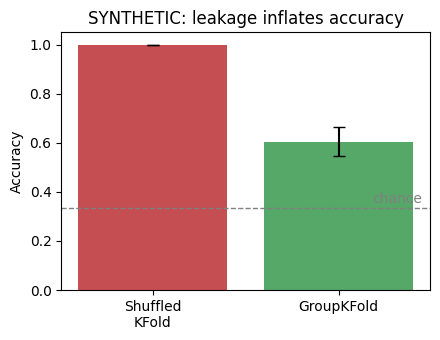

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, GroupKFold, cross_val_score

rng = np.random.default_rng(42)
n_classes, rec_per_class, win_per_rec, n_feat = 3, 6, 50, 10

X, y, g = [], [], []
gid = 0
for c in range(n_classes):
    for r in range(rec_per_class):
        offset = rng.normal(0, 0.6, n_feat)              # recording-specific offset
        base = np.full(n_feat, 0.6 * c)                  # weak true class signal
        for w in range(win_per_rec):
            X.append(base + offset + rng.normal(0, 0.15, n_feat))
            y.append(c); g.append(gid)
        gid += 1
X, y, g = np.array(X), np.array(y), np.array(g)

rf = RandomForestClassifier(n_estimators=12, max_depth=6, random_state=0)
naive   = cross_val_score(rf, X, y, cv=KFold(5, shuffle=True, random_state=0))
grouped = cross_val_score(rf, X, y, cv=GroupKFold(5), groups=g)

print(f"SYNTHETIC data: {len(X)} windows from {gid} recordings")
print(f"Shuffled KFold (leaky)  : {naive.mean():.2f} +/- {naive.std():.2f}")
print(f"GroupKFold (leak-free)  : {grouped.mean():.2f} +/- {grouped.std():.2f}")

fig, ax = plt.subplots(figsize=(4.5, 3.5))
ax.bar(["Shuffled\nKFold", "GroupKFold"], [naive.mean(), grouped.mean()],
       yerr=[naive.std(), grouped.std()], capsize=4, color=["#c44e52", "#55a868"])
ax.axhline(1/3, ls="--", c="gray", lw=1); ax.text(1.45, 1/3+0.02, "chance", ha="right", color="gray")
ax.set_ylim(0, 1.05); ax.set_ylabel("Accuracy")
ax.set_title("SYNTHETIC: leakage inflates accuracy")
plt.tight_layout(); plt.show()

The naive split looks far better because the forest can recognise *which recording* a window came from. That advantage disappears on unseen recordings. This is exactly the inflation our grouped protocol avoids, and it is why we consider 0.84 +/- 0.09 a more defensible estimate than a leaky 0.95+.

## 6. Inspecting the model that runs on the ESP32

`model.h` is the Random Forest exported to C with `micromlgen`. Below we parse that file directly, rebuild the trees in Python, and check its size and structure. This is the **real deployed artifact**, not a re-training.

> **Model versions.** The paper's offline pipeline used 37 window features and 3 target classes. The firmware in `motor_classifier_2class/` is a **2-class (normal / abnormal)** model on **7 raw per-sample features** (`accel_x/y/z`, `gyro_x/y/z`, `period_us`), with a majority vote over 200 samples (about 2 s) to give one dashboard prediction. Both are part of the project, but they are different stages, so we keep them separate.

In [ ]:
import re, os

MODEL_PATH  = "motor_classifier_2class/model.h"
SCALER_PATH = "motor_classifier_2class/scaler_params.h"
assert os.path.exists(MODEL_PATH), "Put the motor_classifier_2class folder next to this notebook."

src = open(MODEL_PATH).read()
parts = re.split(r"//\s*tree\s*#\d+", src)[1:]

TOK = re.compile(r"if \(x\[(\d+)\] <= ([-+0-9.eE]+)\) \{|else \{|\}|votes\[(\d+)\] \+= 1;")

def parse_tree(text):
    toks = [m for m in TOK.finditer(text)]
    pos = 0
    def node():
        nonlocal pos
        m = toks[pos]; pos += 1
        s = m.group(0)
        if s.startswith("votes"):
            return ("leaf", int(m.group(3)))
        assert s.startswith("if"), s
        feat, thr = int(m.group(1)), float(m.group(2))
        left = body()
        assert toks[pos].group(0).startswith("else"); pos += 1
        right = body()
        return ("split", feat, thr, left, right)
    def body():
        nonlocal pos
        n = node()
        assert toks[pos].group(0) == "}"; pos += 1
        return n
    return node()

trees = [parse_tree(p) for p in parts]

def depth(n):  return 0 if n[0] == "leaf" else 1 + max(depth(n[3]), depth(n[4]))
def leaves(n): return 1 if n[0] == "leaf" else leaves(n[3]) + leaves(n[4])
def splits(n, acc):
    if n[0] == "split":
        acc.append(n[1]); splits(n[3], acc); splits(n[4], acc)
    return acc

scaler_src = open(SCALER_PATH).read()
mean  = np.array(eval(re.search(r"feature_mean\[\]\s*=\s*\{(.*?)\}", scaler_src).group(1).replace("f", "")))
scale = np.array(eval(re.search(r"feature_scale\[\]\s*=\s*\{(.*?)\}", scaler_src).group(1).replace("f", "")))
features = ["accel_x", "accel_y", "accel_z", "gyro_x", "gyro_y", "gyro_z", "period_us"]
classes = {0: "normal", 1: "abnormal"}

print(f"Trees parsed        : {len(trees)}")
print(f"Max depth per tree  : {[depth(t) for t in trees]}")
print(f"Leaves per tree     : {[leaves(t) for t in trees]}")
print(f"Total decision nodes: {sum(len(splits(t, [])) for t in trees)}")
print(f"model.h size        : {os.path.getsize(MODEL_PATH)/1024:.1f} KB of source")

Trees parsed        : 12
Max depth per tree  : [6, 6, 6, 5, 5, 5, 4, 4, 4, 6, 4, 6]
Leaves per tree     : [13, 10, 29, 11, 9, 8, 10, 6, 6, 14, 7, 10]
Total decision nodes: 121
model.h size        : 30.0 KB of source


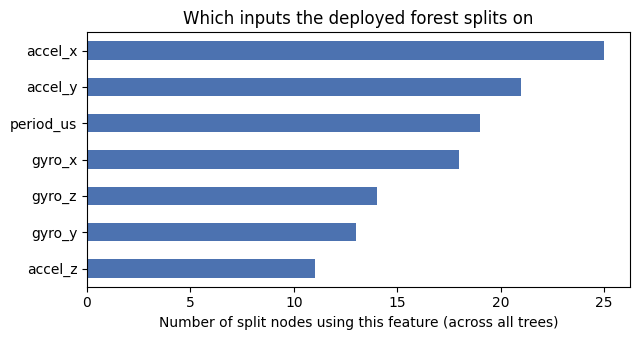

,split count,share %
accel_x,25,20.7
accel_y,21,17.4
period_us,19,15.7
gyro_x,18,14.9
gyro_z,14,11.6
gyro_y,13,10.7
accel_z,11,9.1


,value
Model type,Random Forest (micromlgen export)
Classes,"0 = normal, 1 = abnormal"
Inputs,"accel_x, accel_y, accel_z, gyro_x, gyro_y, gyro_z, period_us"
Trees,12
Max depth,6
Total leaves,133
Total decision nodes,121


,mean,scale
accel_x,2.247504,0.433271
accel_y,-0.996410,1.156042
accel_z,7.808066,0.692936
gyro_x,-0.045526,0.109115
gyro_y,0.051869,0.063647
gyro_z,-0.016687,0.031828
period_us,28832.325983,45807.970604


In [ ]:
from collections import Counter
cnt = Counter(f for t in trees for f in splits(t, []))
imp = pd.Series({features[i]: cnt.get(i, 0) for i in range(7)}).sort_values()

fig, ax = plt.subplots(figsize=(6.5, 3.5))
imp.plot.barh(ax=ax, color="#4c72b0")
ax.set_xlabel("Number of split nodes using this feature (across all trees)")
ax.set_title("Which inputs the deployed forest splits on")
plt.tight_layout(); plt.show()
share = (imp / imp.sum() * 100).round(1)
display(pd.DataFrame({"split count": imp, "share %": share}).sort_values("split count", ascending=False))

summary = pd.DataFrame({"value": {
    "Model type": "Random Forest (micromlgen export)",
    "Classes": "0 = normal, 1 = abnormal",
    "Inputs": ", ".join(features),
    "Trees": len(trees),
    "Max depth": max(depth(t) for t in trees),
    "Total leaves": sum(leaves(t) for t in trees),
    "Total decision nodes": int(imp.sum()),
}})
display(summary)
display(pd.DataFrame({"mean": mean, "scale": scale}, index=features))

**Observation for discussion:** this counts how often each input is *used* in a split. It is a rough indicator, not a proper importance measure. `period_us` (the Hall pulse period, i.e. motor speed) is used in about 16% of splits, so it does not dominate by count, but it is the first split of tree 1. A model can still partly recognise *operating speed* rather than the fault itself, which is a risk when the normal and abnormal recordings were taken at different speeds. Checking this (for example by evaluating at matched speeds) is a sensible next step.

### 6.1 Running the exported model in Python

The firmware standardises each raw sample with `(x - mean) / scale` and then lets the trees vote. We reproduce that exactly. The example inputs below are **hand-picked illustrations, not recorded measurements**. A point built from the training means is not a real sample, so the labels printed here say nothing about the model's accuracy; they only show the pipeline (scale, then vote) working end to end.

**Verification:** we compiled `model.h` with a C++ compiler and compared it with this Python re-implementation on 5,000 random scaled inputs, with 0 disagreements. So the Python port behaves like the code on the ESP32.

In [ ]:
def tree_predict(n, x):
    while n[0] == "split":
        n = n[3] if x[n[1]] <= n[2] else n[4]
    return n[1]

def predict_sample(raw):
    x = (np.asarray(raw, dtype=float) - mean) / scale
    votes = np.zeros(2, int)
    for t in trees:
        votes[tree_predict(t, x)] += 1
    return int(votes.argmax()), votes

np.set_printoptions(suppress=True, precision=4)
print("Scaler mean :", mean)
print("Scaler scale:", scale)
print()

examples = {
    "near training mean (illustrative)": mean,
    "shifted +2 sigma on all axes (illustrative)": mean + 2*scale,
    "shifted -2 sigma on all axes (illustrative)": mean - 2*scale,
}
for name, raw in examples.items():
    cls, votes = predict_sample(raw)
    print(f"{name:45s} -> {classes[cls]:9s} votes normal/abnormal = {votes[0]}/{votes[1]}")

Scaler mean : [    2.2475    -0.9964     7.8081    -0.0455     0.0519    -0.0167
 28832.326 ]
Scaler scale: [    0.4333     1.156      0.6929     0.1091     0.0636     0.0318
 45807.9706]

near training mean (illustrative)             -> abnormal  votes normal/abnormal = 4/8
shifted +2 sigma on all axes (illustrative)   -> normal    votes normal/abnormal = 10/2
shifted -2 sigma on all axes (illustrative)   -> abnormal  votes normal/abnormal = 2/10


### 6.2 Window-level majority vote (as in the firmware)

The ESP32 classifies each of 200 samples and reports the class with more votes. This smooths single-sample noise. Below we mimic that with a **synthetic** window of noisy samples around the training means. The output is only a demonstration of the voting mechanism, not a claim about real motor data.

In [ ]:
def classify_window(samples):
    votes = np.zeros(2, int)
    for s in samples:
        cls, _ = predict_sample(s)
        votes[cls] += 1
    return ("abnormal" if votes[1] > votes[0] else "normal"), votes

rng = np.random.default_rng(1)
WIN = 200
window = mean + rng.normal(0, 1, (WIN, 7)) * scale * 0.5      # SYNTHETIC noisy samples
label, votes = classify_window(window)
print(f"SYNTHETIC window of {WIN} samples -> {label}  (normal={votes[0]}, abnormal={votes[1]})")
print("Firmware rule: if the motor is stopped (duty = 0) it reports 'normal' without classifying.")

SYNTHETIC window of 200 samples -> abnormal  (normal=91, abnormal=109)
Firmware rule: if the motor is stopped (duty = 0) it reports 'normal' without classifying.


## 7. Live dashboard and firmware telemetry

The ESP32 prints one line about every 2 s and a browser dashboard (Web Serial, Chrome/Edge) plots it:

```
DATA,period_us,rpm,ax_rms,ay_rms,az_rms,overall_rms,temp_c,prediction,duty,direction
```

Below is a parser for that line format, using a **made-up example line** to show what the dashboard extracts.

In [ ]:
line = "DATA,50000.00,1200.0,0.412,0.980,7.812,4.560,31.20,normal,180,Forward"   # made-up example
cols = ["period_us","rpm","ax_rms","ay_rms","az_rms","overall_rms","temp_c","prediction","duty","direction"]
vals = line.split(",")[1:]
rec = dict(zip(cols, vals))
for k in cols[:7] + ["duty"]:
    rec[k] = float(rec[k])
rec["pwm_percent"] = round(rec["duty"] / 255 * 100)
pd.Series(rec).to_frame("value")

,value
period_us,50000.0
rpm,1200.0
ax_rms,0.412
ay_rms,0.98
az_rms,7.812
overall_rms,4.56
temp_c,31.2
prediction,normal
duty,180.0
direction,Forward


## 8. Limitations (as stated in our report)

- Few recording segments, so cross-validation accuracy is noisy (+/- 0.09).
- **Misalignment** data is not yet collected; the rig can reproduce it but it is not in the current dataset.
- Only the deployed model's grouped-CV accuracy is fully confirmed; a formal head-to-head of all six classifiers under identical conditions is still to be completed.
- No confusion matrix yet for the final compressed model.
- FFT-based features are not yet in the live firmware.
- The live dashboard is not fully stable during long continuous streaming.
- No authentication or encryption (local USB serial only), which is acceptable for a bench prototype but must be added before any cloud publishing.

## 9. Future work

1. Complete the formal six-classifier comparison under identical grouped-CV conditions.
2. Collect Misalignment data and move to a 3-class on-device model.
3. Produce and analyse a confusion matrix.
4. Stabilise the dashboard and integrate FFT features on-device.
5. Time-series database plus secured cloud monitoring (ThingSpeak / Firebase).
6. Close the loop: automatically slow or stop the motor on a predicted fault.

## References

1. S. Soni and A. Kori, "IoT-based Predictive Maintenance System for Industrial Machines with Machine Learning Algorithms," *IJIREM*, vol. 13, no. 3, pp. 78-84, 2026.
2. P. Kolok et al., "Low-Cost IoT-Based Predictive Maintenance Using Vibration and Acoustic Sensing on an ESP32 Platform," *Sensors*, vol. 25, no. 21, art. 6610, 2025.
3. S. Asutkar et al., "TinyML-enabled edge implementation of transfer learning framework for domain generalization in machine fault diagnosis," *Expert Systems with Applications*, vol. 213, art. 119016, 2023.
4. J. P. Vieira et al., "Towards a more realistic evaluation of machine learning models for bearing fault diagnosis," arXiv:2509.22267, 2025.